# ViT-B16 Transfer Learning


In [ ]:
!pip install onedrivedownloader

In [ ]:
from onedrivedownloader import download
download("https://centennialcollegeedu-my.sharepoint.com/:u:/g/personal/dlytvyn_my_centennialcollege_ca/IQBVteiGClxAS783D-5VtWenAbRiVqrV7E2ZjD8L9BMiL-E?e=qB5a8D&download=1", filename="iwildcam-2019-fgvc6.zip", unzip=True)

In [1]:
# Standard library utilities for file paths, reproducibility, copying checkpoints, and timing.
from pathlib import Path
import copy
import json
import math
import random
import time

# Core training, plotting, metrics, and augmentation libraries.
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import timm
import torch
from PIL import Image
from sklearn.metrics import accuracy_score, balanced_accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.utils.class_weight import compute_class_weight
from timm.data import resolve_data_config
from torch import nn
from torch.optim.lr_scheduler import ReduceLROnPlateau
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms
from tqdm.auto import tqdm

sns.set_theme(style='whitegrid')
torch.backends.cudnn.benchmark = True


In [2]:
# Pretrained checkpoint name used by timm.
MODEL_NAME = 'ViT-B16'
MODEL_SLUG = 'vit_b16_transfer_learning'
TIMM_MODEL_NAME = 'vit_base_patch16_224.augreg2_in21k_ft_in1k'
RANDOM_SEED = 42

# Split ratios for train, validation, and test.
TRAIN_FRACTION = 0.8
VALID_FRACTION = 0.1
TEST_FRACTION = 0.1

# Core optimization settings.
BATCH_SIZE = 32
EARLY_STOPPING_PATIENCE = 4
LR_PATIENCE = 2
NUM_WORKERS = 0
WEIGHT_DECAY = 1e-4
LABEL_SMOOTHING = 0.05
RUN_TRAINING = False

# Stage 1 only trains the new classifier head.
STAGE_1_NAME = 'head_only'
STAGE_1_EPOCHS = 5
STAGE_1_LEARNING_RATE = 1e-3
STAGE_1_UNFREEZE_BLOCKS = 0
STAGE_1_EXTRA_MODULES = []

# Stage 2 opens the last backbone blocks for lighter fine-tuning.
STAGE_2_NAME = 'last_layers_finetune'
STAGE_2_EPOCHS = 5
STAGE_2_LEARNING_RATE = 3e-4
STAGE_2_UNFREEZE_BLOCKS = 2
STAGE_2_EXTRA_MODULES = ['norm', 'fc_norm', 'conv_head', 'bn2']

# Stage 3 opens more of the backbone and lowers the learning rate again.
STAGE_3_NAME = 'deeper_finetune'
STAGE_3_EPOCHS = 3
STAGE_3_LEARNING_RATE = 1e-4
STAGE_3_UNFREEZE_BLOCKS = 6
STAGE_3_EXTRA_MODULES = ['norm', 'fc_norm', 'conv_head', 'bn2']

# Original dataset labels mapped to readable class names.
CATEGORY_NAME_MAP = {
    0: 'empty',
    1: 'deer',
    2: 'moose',
    3: 'squirrel',
    4: 'rodent',
    5: 'small_mammal',
    6: 'elk',
    7: 'pronghorn_antelope',
    8: 'rabbit',
    9: 'bighorn_sheep',
    10: 'fox',
    11: 'coyote',
    12: 'black_bear',
    13: 'raccoon',
    14: 'skunk',
    15: 'wolf',
    16: 'bobcat',
    17: 'cat',
    18: 'dog',
    19: 'opossum',
    20: 'bison',
    21: 'mountain_goat',
    22: 'mountain_lion',
}


In [5]:
# Seed Python, NumPy, and PyTorch for reproducible splits and initialization.
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)
torch.cuda.manual_seed_all(RANDOM_SEED)

# Switch paths automatically depending on whether the notebook runs in Colab.
try:
    import google.colab  # type: ignore
    running_in_colab = True
except ModuleNotFoundError:
    running_in_colab = False

if running_in_colab:
    data_dir = Path('/content/iwildcam-2019-fgvc6')
    models_root = Path('/content/models')
    print('Running in Colab')
else:
    data_dir = Path('iwildcam-2019-fgvc6')
    models_root = Path('models')
    print('Running locally')

# Reuse these paths throughout the notebook.
train_csv_path = data_dir / 'train_without_empty.csv'
train_image_dir = data_dir / 'train_images'
checkpoint_dir = models_root / MODEL_SLUG
checkpoint_dir.mkdir(parents=True, exist_ok=True)

# Enable mixed precision only when a CUDA GPU is available.
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
use_amp = device.type == 'cuda'

print(f'Device: {device}')
print(f'CSV path exists: {train_csv_path.exists()}')
print(f'Image directory exists: {train_image_dir.exists()}')
print(f'Checkpoint directory: {checkpoint_dir}')


Running locally
Device: cuda
CSV path exists: True
Image directory exists: True
Checkpoint directory: models\vit_b16_transfer_learning


In [6]:
# Load the metadata table generated from the non-empty training subset.
train_df = pd.read_csv(train_csv_path)
# Add readable class names for summaries and plots.
train_df['category_name'] = train_df['category_id'].map(CATEGORY_NAME_MAP)
train_df['image_path'] = train_df['file_name'].map(lambda name: train_image_dir / name)
train_df['image_exists'] = train_df['image_path'].map(Path.exists)

# Drop rows whose image files are missing from the extracted image folder.
filtered_df = train_df[train_df['image_exists']].copy()
# Remove the empty class and mountain lion samples so the model focuses on the remaining animal categories.
filtered_df = filtered_df[~filtered_df['category_id'].isin([0, 22])].copy()

# Deduplicate by seq_id: keep the first frame of each camera sequence.
filtered_df = filtered_df.sort_values('frame_num').drop_duplicates(subset='seq_id', keep='first').reset_index(drop=True).copy()

# Convert sparse dataset ids into contiguous label indices for PyTorch.
unique_category_ids = sorted(filtered_df['category_id'].unique())
category_to_index = {category_id: index for index, category_id in enumerate(unique_category_ids)}
class_names = [CATEGORY_NAME_MAP[category_id] for category_id in unique_category_ids]
filtered_df['label_index'] = filtered_df['category_id'].map(category_to_index)

# Preserve class ratios in every split with stratified sampling.
stratify_labels = filtered_df['label_index'].to_numpy()
all_indices = np.arange(len(filtered_df))
first_split = StratifiedShuffleSplit(n_splits=1, train_size=TRAIN_FRACTION, random_state=RANDOM_SEED)
train_indices, holdout_indices = next(first_split.split(all_indices, stratify_labels))
train_split_df = filtered_df.iloc[train_indices].reset_index(drop=True)
holdout_df = filtered_df.iloc[holdout_indices].reset_index(drop=True)

holdout_labels = holdout_df['label_index'].to_numpy()
holdout_row_indices = np.arange(len(holdout_df))
second_split = StratifiedShuffleSplit(n_splits=1, train_size=0.5, random_state=RANDOM_SEED)
valid_indices, test_indices = next(second_split.split(holdout_row_indices, holdout_labels))
valid_split_df = holdout_df.iloc[valid_indices].reset_index(drop=True)
test_split_df = holdout_df.iloc[test_indices].reset_index(drop=True)

# Summarize split sizes for a quick sanity check.
split_summary_df = pd.DataFrame([
    {'split': 'train', 'rows': len(train_split_df)},
    {'split': 'validation', 'rows': len(valid_split_df)},
    {'split': 'test', 'rows': len(test_split_df)},
])

# Verify that each split keeps roughly the same class distribution.
split_class_summary_df = pd.concat([
    train_split_df.assign(split='train'),
    valid_split_df.assign(split='validation'),
    test_split_df.assign(split='test'),
])
split_class_summary_df = (
    split_class_summary_df.groupby(['split', 'category_name'])
    .size()
    .reset_index(name='image_count')
)

print(f'Total usable rows: {len(filtered_df):,}')
print(f'Number of classes: {len(class_names)}')
display(split_summary_df)
display(split_class_summary_df)


Total usable rows: 64,842
Number of classes: 13


,split,rows
0,train,51873
1,validation,6484
2,test,6485


,split,category_name,image_count
0,test,bobcat,598
1,test,cat,476
2,test,coyote,721
3,test,deer,610
4,test,dog,303
5,test,fox,109
6,test,mountain_lion,3
7,test,opossum,1411
8,test,rabbit,694
9,test,raccoon,863


In [7]:
# Build the pretrained model once to inspect its expected preprocessing settings.
reference_model = timm.create_model(TIMM_MODEL_NAME, pretrained=True)
data_config = resolve_data_config({}, model=reference_model)
del reference_model

# Read image size and normalization statistics from the pretrained checkpoint metadata.
image_size = data_config['input_size'][1:]
resize_size = tuple(image_size)
mean = data_config['mean']
std = data_config['std']

# Keep validation and test deterministic.
eval_transform = transforms.Compose([
    transforms.Resize(resize_size),
    transforms.ToTensor(),
    transforms.Normalize(mean=mean, std=std),
])

# ViT benefits more from crop-based augmentation than from plain resizing.
train_transform = transforms.Compose([
    transforms.RandomResizedCrop(resize_size, scale=(0.8, 1.0), interpolation=transforms.InterpolationMode.BICUBIC),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ColorJitter(brightness=0.15, contrast=0.15, saturation=0.1, hue=0.02),
    transforms.ToTensor(),
    transforms.Normalize(mean=mean, std=std),
    transforms.RandomErasing(p=0.1, scale=(0.02, 0.12), ratio=(0.3, 3.3), value='random'),
])

print(json.dumps(data_config, indent=2, default=str))


{
  "input_size": [
    3,
    224,
    224
  ],
  "interpolation": "bicubic",
  "mean": [
    0.5,
    0.5,
    0.5
  ],
  "std": [
    0.5,
    0.5,
    0.5
  ],
  "crop_pct": 0.9,
  "crop_mode": "center"
}


In [8]:
# Dataset returns one transformed image tensor and its label index.
class WildlifeDataset(Dataset):
    def __init__(self, dataframe: pd.DataFrame, transform):
        self.dataframe = dataframe.reset_index(drop=True)
        self.transform = transform

    def __len__(self) -> int:
        return len(self.dataframe)

    def __getitem__(self, index: int):
        row = self.dataframe.iloc[index]
        with Image.open(row['image_path']) as image:
            image = image.convert('RGB')

        image = self.transform(image)
        return image, int(row['label_index'])


# Training uses augmentation, validation and test use deterministic preprocessing.
train_dataset = WildlifeDataset(train_split_df, transform=train_transform)
valid_dataset = WildlifeDataset(valid_split_df, transform=eval_transform)
test_dataset = WildlifeDataset(test_split_df, transform=eval_transform)

# Keep worker processes alive between batches when multiprocessing is enabled.
persistent_workers = NUM_WORKERS > 0
pin_memory = device.type == 'cuda'

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS, pin_memory=pin_memory, persistent_workers=persistent_workers)
valid_loader = DataLoader(valid_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=pin_memory, persistent_workers=persistent_workers)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=pin_memory, persistent_workers=persistent_workers)

# Class weights reduce the influence of class imbalance in the loss.
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_split_df['label_index']),
    y=train_split_df['label_index'],
)
class_weights_tensor = torch.tensor(class_weights, dtype=torch.float32, device=device)
criterion = nn.CrossEntropyLoss(weight=class_weights_tensor, label_smoothing=LABEL_SMOOTHING)

print(f'Train batches: {len(train_loader)}')
print(f'Validation batches: {len(valid_loader)}')
print(f'Test batches: {len(test_loader)}')
display(pd.DataFrame({'class_name': class_names, 'class_weight': class_weights}))


Train batches: 1622
Validation batches: 203
Test batches: 203


,class_name,class_weight
0,deer,0.817335
1,squirrel,1.468076
2,rodent,2.256918
3,rabbit,0.718960
4,fox,4.565481
5,coyote,0.691908
6,raccoon,0.578462
7,skunk,3.664124
8,bobcat,0.834776
9,cat,1.048130


In [10]:
# Rebuild the pretrained backbone and replace the classifier with the right output size.
def build_model(num_classes: int) -> nn.Module:
    model = timm.create_model(TIMM_MODEL_NAME, pretrained=True)
    model.reset_classifier(num_classes=num_classes)
    return model


# Freeze or unfreeze parameters depending on the current fine-tuning stage.
def apply_stage_freezing(model: nn.Module, unfreeze_blocks: int, extra_modules) -> None:
    # Start from a fully frozen pretrained network.
    for parameter in model.parameters():
        parameter.requires_grad = False

    # The classifier head always stays trainable because it must adapt to the new classes.
    for parameter in model.get_classifier().parameters():
        parameter.requires_grad = True

    # Some architectures expose extra normalization or head-adjacent modules that are safe
    # to fine-tune before unfreezing a larger part of the backbone.
    for module_name in extra_modules:
        module = getattr(model, module_name, None)
        if module is not None:
            for parameter in module.parameters():
                parameter.requires_grad = True

    # Deeper stages unfreeze the last backbone blocks so gradients can update more of the
    # pretrained feature extractor while still keeping most low-level features intact.
    if hasattr(model, 'blocks') and unfreeze_blocks > 0:
        blocks = list(model.blocks)
        for block in blocks[-unfreeze_blocks:]:
            for parameter in block.parameters():
                parameter.requires_grad = True


# Count trainable versus frozen parameters to confirm the stage setup.
def summarize_trainable_parameters(model: nn.Module) -> pd.DataFrame:
    rows = []
    for name, parameter in model.named_parameters():
        rows.append({
            'parameter_name': name,
            'trainable': parameter.requires_grad,
            'parameter_count': parameter.numel(),
        })
    summary_df = pd.DataFrame(rows)
    return summary_df.groupby('trainable', as_index=False)['parameter_count'].sum().sort_values('trainable', ascending=False)


# Stop a stage early once validation loss stops improving.
class EarlyStopping:
    def __init__(self, patience: int, min_delta: float = 0.0):
        self.patience = patience
        self.min_delta = min_delta
        self.best_value = math.inf
        self.bad_epochs = 0

    def step(self, current_value: float) -> bool:
        if current_value < self.best_value - self.min_delta:
            self.best_value = current_value
            self.bad_epochs = 0
            return False
        self.bad_epochs += 1
        return self.bad_epochs >= self.patience


# Shared loop for one training epoch or one evaluation pass.
def run_one_epoch(model: nn.Module, dataloader: DataLoader, optimizer=None, progress_label: str = 'epoch') -> dict:
    is_training = optimizer is not None
    # Switch between training mode and evaluation mode.
    model.train(is_training)
    scaler = torch.cuda.amp.GradScaler(enabled=use_amp)

    running_loss = 0.0
    all_targets = []
    all_predictions = []
    # tqdm shows live batch progress for both training and evaluation passes.
    progress_bar = tqdm(dataloader, desc=progress_label, leave=True, dynamic_ncols=True)

    for images, labels in progress_bar:
        # Move the current batch to the selected device.
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        if is_training:
            # Clear old gradients before computing new ones for this batch.
            optimizer.zero_grad(set_to_none=True)

        # Enable autograd only during training.
        with torch.set_grad_enabled(is_training):
            # Forward pass: compute logits for the current batch.
            with torch.cuda.amp.autocast(enabled=use_amp):
                logits = model(images)
                # Compare logits against the ground-truth labels.
                loss = criterion(logits, labels)

            if is_training:
                # Backward pass: propagate the loss through the trainable parameters.
                scaler.scale(loss).backward()
                # Optimizer step: update the trainable parameters for this stage.
                scaler.step(optimizer)
                scaler.update()

        # Convert logits into discrete class predictions with argmax.
        predictions = logits.argmax(dim=1)
        running_loss += loss.item() * images.size(0)
        all_targets.extend(labels.detach().cpu().tolist())
        all_predictions.extend(predictions.detach().cpu().tolist())
        progress_bar.set_postfix(loss=f'{loss.item():.4f}')

    report_dict = classification_report(all_targets, all_predictions, target_names=class_names, output_dict=True, zero_division=0)
    return {
        'loss': running_loss / len(dataloader.dataset),
        'accuracy': accuracy_score(all_targets, all_predictions),
        'balanced_accuracy': balanced_accuracy_score(all_targets, all_predictions),
        'macro_f1': report_dict['macro avg']['f1-score'],
    }


# Run one fine-tuning stage, save the best checkpoint, and return the stage history.
def train_stage(model: nn.Module, stage_name: str, epochs: int, learning_rate: float, unfreeze_blocks: int, extra_modules):
    # Reconfigure which parts of the pretrained model are allowed to learn in this stage.
    apply_stage_freezing(model, unfreeze_blocks, extra_modules)

    # Build an optimizer using only the parameters that are currently trainable.
    optimizer = torch.optim.AdamW(
        [parameter for parameter in model.parameters() if parameter.requires_grad],
        lr=learning_rate,
        weight_decay=WEIGHT_DECAY,
    )
    # Lower the learning rate automatically when validation loss plateaus.
    scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=LR_PATIENCE)

    # Stop the stage once validation loss stops improving for several epochs.
    early_stopper = EarlyStopping(patience=EARLY_STOPPING_PATIENCE)

    stage_history = []
    best_state_dict = copy.deepcopy(model.state_dict())
    best_valid_loss = math.inf
    stage_checkpoint_path = checkpoint_dir / f'{stage_name}_best.pt'
    overall_checkpoint_path = checkpoint_dir / 'best_model.pt'

    print('-' * 80)
    print(f'Starting stage: {stage_name}')
    display(summarize_trainable_parameters(model))

    # Each epoch runs one full training pass and one full validation pass.
    for epoch in range(epochs):
        epoch_start = time.time()
        train_metrics = run_one_epoch(model, train_loader, optimizer=optimizer, progress_label=f'train {stage_name} e{epoch + 1}')
        valid_metrics = run_one_epoch(model, valid_loader, progress_label=f'valid {stage_name} e{epoch + 1}')

        # Update the scheduler after validation so it reacts to generalization, not training loss.
        scheduler.step(valid_metrics['loss'])

        history_row = {
            'stage_name': stage_name,
            'epoch': epoch + 1,
            'learning_rate': optimizer.param_groups[0]['lr'],
            'train_loss': train_metrics['loss'],
            'train_accuracy': train_metrics['accuracy'],
            'train_balanced_accuracy': train_metrics['balanced_accuracy'],
            'train_macro_f1': train_metrics['macro_f1'],
            'valid_loss': valid_metrics['loss'],
            'valid_accuracy': valid_metrics['accuracy'],
            'valid_balanced_accuracy': valid_metrics['balanced_accuracy'],
            'valid_macro_f1': valid_metrics['macro_f1'],
            'epoch_seconds': time.time() - epoch_start,
        }
        stage_history.append(history_row)
        print(history_row)

        # Keep the best-performing weights seen so far in this stage.
        if valid_metrics['loss'] < best_valid_loss:
            best_valid_loss = valid_metrics['loss']
            best_state_dict = copy.deepcopy(model.state_dict())
            checkpoint_payload = {
                'model_name': MODEL_NAME,
                'timm_model_name': TIMM_MODEL_NAME,
                'stage_name': stage_name,
                'model_state_dict': best_state_dict,
                'class_names': class_names,
                'category_to_index': category_to_index,
                'data_config': data_config,
                'stage_history': stage_history,
            }
            torch.save(checkpoint_payload, stage_checkpoint_path)
            torch.save(checkpoint_payload, overall_checkpoint_path)

        # End the stage early when validation loss no longer improves enough.
        if early_stopper.step(valid_metrics['loss']):
            print(f'Early stopping triggered in stage {stage_name}')
            break

    # Restore the best weights before moving to the next stage.
    model.load_state_dict(best_state_dict)
    return model, stage_history


# Collect predictions once so multiple metrics and plots can reuse them.
def collect_predictions(model: nn.Module, dataloader: DataLoader, progress_label: str):
    model.eval()
    all_targets = []
    all_predictions = []

    with torch.inference_mode():
        for images, labels in tqdm(dataloader, desc=progress_label, leave=True, dynamic_ncols=True):
            images = images.to(device, non_blocking=True)
            logits = model(images)
            predictions = logits.argmax(dim=1)
            all_targets.extend(labels.numpy().tolist())
            all_predictions.extend(predictions.cpu().numpy().tolist())

    return np.array(all_targets), np.array(all_predictions)


# Report metrics and visualization artifacts for one split.
def evaluate_split(model: nn.Module, dataloader: DataLoader, split_name: str):
    targets, predictions = collect_predictions(model, dataloader, progress_label=f'{split_name.lower()} eval')
    report_dict = classification_report(targets, predictions, target_names=class_names, output_dict=True, zero_division=0)

    metrics_df = pd.DataFrame([
        {'metric': 'accuracy', 'value': accuracy_score(targets, predictions)},
        {'metric': 'balanced_accuracy', 'value': balanced_accuracy_score(targets, predictions)},
        {'metric': 'macro_precision', 'value': report_dict['macro avg']['precision']},
        {'metric': 'macro_recall', 'value': report_dict['macro avg']['recall']},
        {'metric': 'macro_f1', 'value': report_dict['macro avg']['f1-score']},
    ])
    report_df = pd.DataFrame(report_dict).transpose().reset_index().rename(columns={'index': 'label'})

    confusion = confusion_matrix(targets, predictions, labels=list(range(len(class_names))))
    plt.figure(figsize=(12, 10))
    sns.heatmap(confusion, cmap='Blues', annot=True, fmt='d', xticklabels=class_names, yticklabels=class_names)
    plt.title(f'{split_name} Confusion Matrix')
    plt.xlabel('Predicted label')
    plt.ylabel('True label')
    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()

    per_class_df = report_df[report_df['label'].isin(class_names)][['label', 'f1-score', 'support']].copy()
    plt.figure(figsize=(12, 5))
    sns.barplot(data=per_class_df, x='label', y='f1-score', color='steelblue')
    plt.title(f'{split_name} Per-Class F1')
    plt.xlabel('Class')
    plt.ylabel('F1 score')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

    return metrics_df, report_df


In [14]:
# Create the model once before optionally running the three training stages.
model = build_model(num_classes=len(class_names)).to(device)

if RUN_TRAINING:
    all_history = []

    model, stage_1_history = train_stage(
        model,
        stage_name=STAGE_1_NAME,
        epochs=STAGE_1_EPOCHS,
        learning_rate=STAGE_1_LEARNING_RATE,
        unfreeze_blocks=STAGE_1_UNFREEZE_BLOCKS,
        extra_modules=STAGE_1_EXTRA_MODULES,
    )
    all_history.extend(stage_1_history)

    model, stage_2_history = train_stage(
        model,
        stage_name=STAGE_2_NAME,
        epochs=STAGE_2_EPOCHS,
        learning_rate=STAGE_2_LEARNING_RATE,
        unfreeze_blocks=STAGE_2_UNFREEZE_BLOCKS,
        extra_modules=STAGE_2_EXTRA_MODULES,
    )
    all_history.extend(stage_2_history)

    model, stage_3_history = train_stage(
        model,
        stage_name=STAGE_3_NAME,
        epochs=STAGE_3_EPOCHS,
        learning_rate=STAGE_3_LEARNING_RATE,
        unfreeze_blocks=STAGE_3_UNFREEZE_BLOCKS,
        extra_modules=STAGE_3_EXTRA_MODULES,
    )
    all_history.extend(stage_3_history)

    history_df = pd.DataFrame(all_history)
    history_path = checkpoint_dir / 'training_history.csv'
    history_df.to_csv(history_path, index=False)
    print(f'Saved training history to {history_path}')
else:
    history_df = pd.DataFrame()
    print('RUN_TRAINING is False, so no training was started.')


RUN_TRAINING is False, so no training was started.


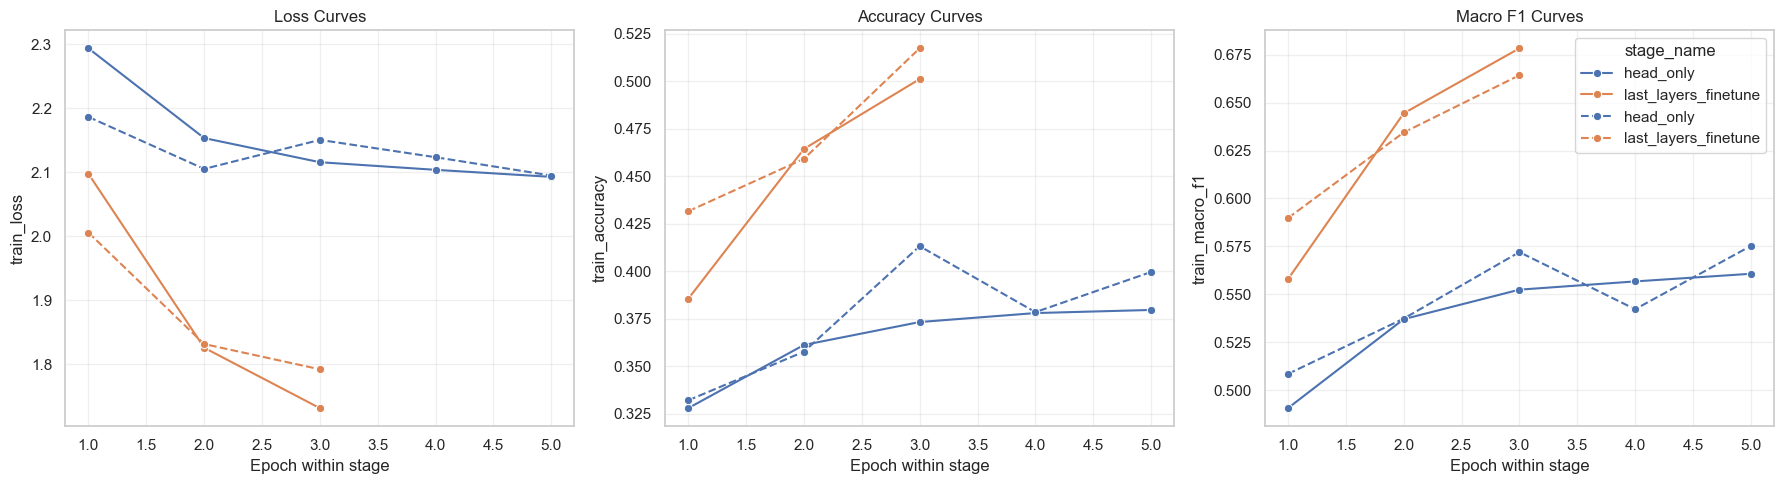

In [15]:
# Reload history if training was run in an earlier session.
history_path = checkpoint_dir / 'training_history.csv'
if history_df.empty and history_path.exists():
    history_df = pd.read_csv(history_path)

if history_df.empty:
    print('No training history is available yet.')
else:
    plot_df = history_df.copy()
    plot_df['stage_epoch'] = plot_df.groupby('stage_name').cumcount() + 1

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    sns.lineplot(data=plot_df, x='stage_epoch', y='train_loss', hue='stage_name', marker='o', ax=axes[0], legend=False)
    sns.lineplot(data=plot_df, x='stage_epoch', y='valid_loss', hue='stage_name', marker='o', linestyle='--', ax=axes[0], legend=False)
    axes[0].set_title('Loss Curves')

    sns.lineplot(data=plot_df, x='stage_epoch', y='train_accuracy', hue='stage_name', marker='o', ax=axes[1], legend=False)
    sns.lineplot(data=plot_df, x='stage_epoch', y='valid_accuracy', hue='stage_name', marker='o', linestyle='--', ax=axes[1], legend=False)
    axes[1].set_title('Accuracy Curves')

    sns.lineplot(data=plot_df, x='stage_epoch', y='train_macro_f1', hue='stage_name', marker='o', ax=axes[2])
    sns.lineplot(data=plot_df, x='stage_epoch', y='valid_macro_f1', hue='stage_name', marker='o', linestyle='--', ax=axes[2])
    axes[2].set_title('Macro F1 Curves')

    for axis in axes:
        axis.set_xlabel('Epoch within stage')
        axis.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()


Loaded checkpoint from stage: last_layers_finetune


validation eval:   0%|          | 0/203 [00:00<?, ?it/s]

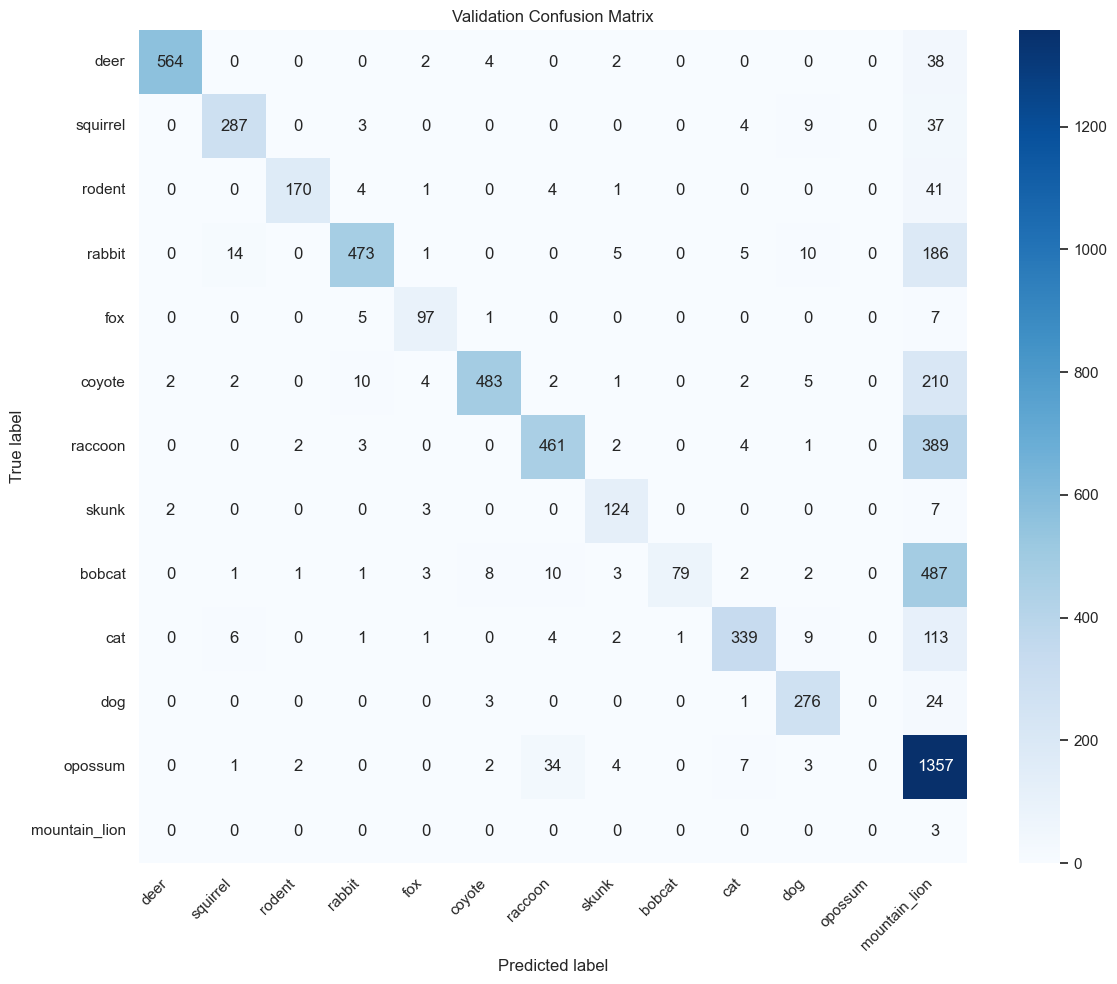

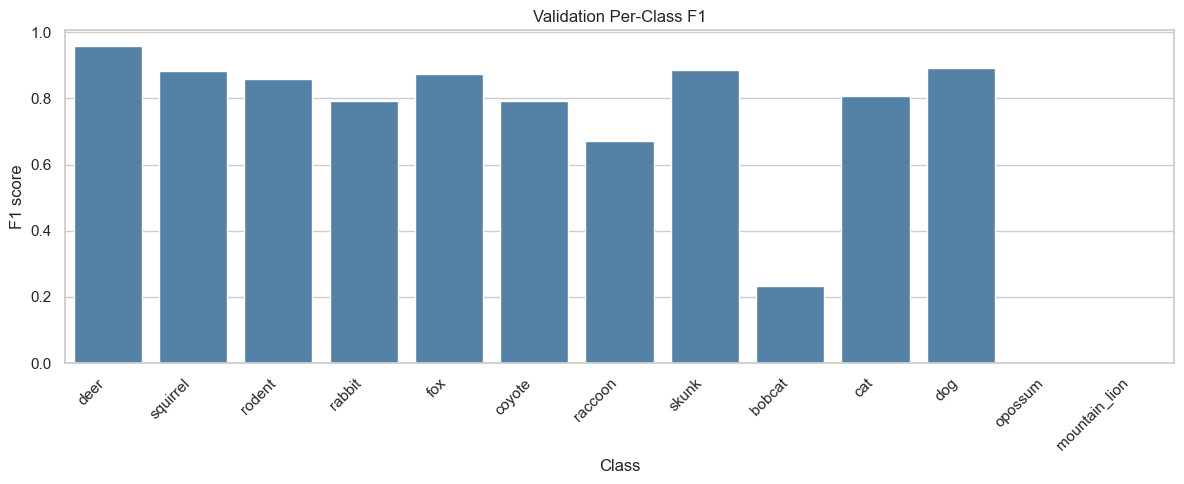

test eval:   0%|          | 0/203 [00:00<?, ?it/s]

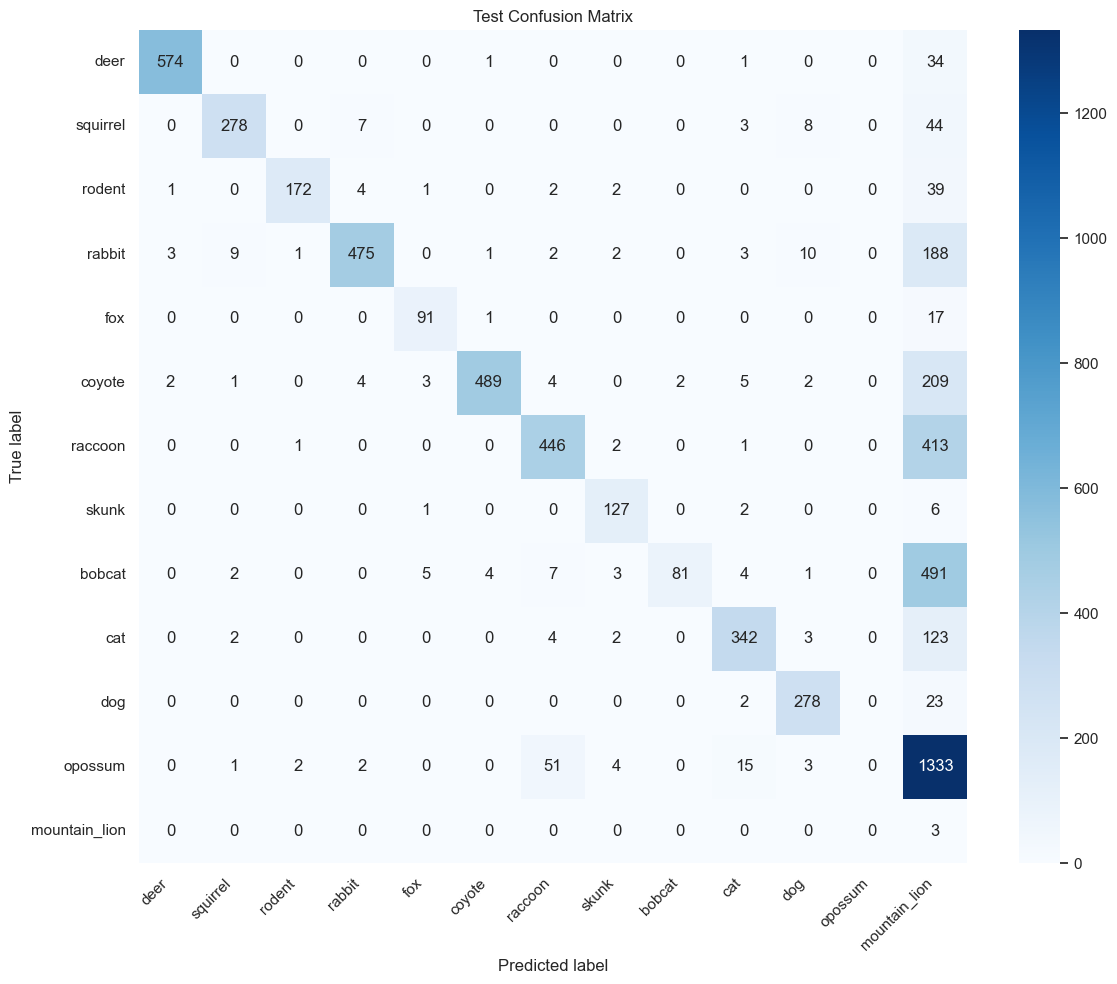

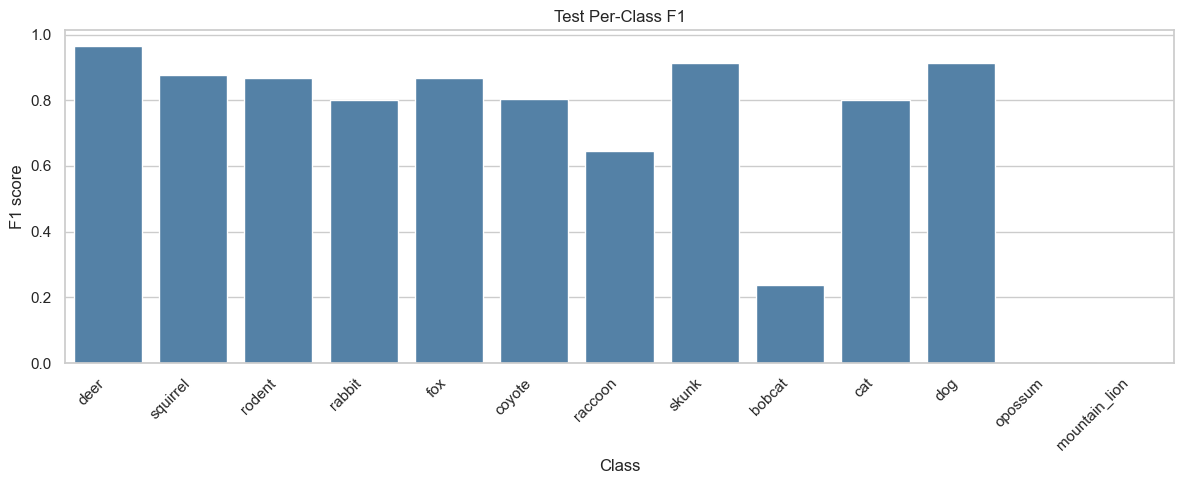

Validation metrics:


,metric,value
0,accuracy,0.517582
1,balanced_accuracy,0.690015
2,macro_precision,0.785820
3,macro_recall,0.690015
4,macro_f1,0.664937


Test metrics:


,metric,value
0,accuracy,0.517502
1,balanced_accuracy,0.688961
2,macro_precision,0.793841
3,macro_recall,0.688961
4,macro_f1,0.668978


Test classification report:


,label,precision,recall,f1-score,support
0,deer,0.989655,0.940984,0.964706,610.000000
1,squirrel,0.948805,0.817647,0.878357,340.000000
2,rodent,0.977273,0.778281,0.866499,221.000000
3,rabbit,0.965447,0.684438,0.801012,694.000000
4,fox,0.900990,0.834862,0.866667,109.000000
5,coyote,0.985887,0.678225,0.803615,721.000000
6,raccoon,0.864341,0.516802,0.646846,863.000000
7,skunk,0.894366,0.933824,0.913669,136.000000
8,bobcat,0.975904,0.135452,0.237885,598.000000
9,cat,0.904762,0.718487,0.800937,476.000000


In [12]:
# Load the best saved checkpoint and evaluate without retraining.
best_checkpoint_path = checkpoint_dir / 'best_model.pt'

if best_checkpoint_path.exists():
    best_model = build_model(num_classes=len(class_names)).to(device)
    checkpoint = torch.load(best_checkpoint_path, map_location=device,weights_only=False)
    best_model.load_state_dict(checkpoint['model_state_dict'])
    print(f'Loaded checkpoint from stage: {checkpoint["stage_name"]}')

    validation_metrics_df, validation_report_df = evaluate_split(best_model, valid_loader, 'Validation')
    test_metrics_df, test_report_df = evaluate_split(best_model, test_loader, 'Test')

    print('Validation metrics:')
    display(validation_metrics_df)
    print('Test metrics:')
    display(test_metrics_df)
    print('Test classification report:')
    display(test_report_df)
else:
    print('No saved checkpoint found yet. Turn on RUN_TRAINING when you are ready to train.')
